In [1]:
import os
import json
os.environ["OMP_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN, HierarchicalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils

paths = [
    'Apr-17-2025-11-24-02', 'Apr-07-2025-08-54-44', 'Apr-07-2025-09-21-14', 'Apr-07-2025-09-49-04',
    'Apr-17-2025-12-13-42', 'Apr-07-2025-10-44-41', 'Apr-07-2025-11-21-24', 'Apr-07-2025-11-57-32', 
    'Apr-17-2025-13-26-02', 'Apr-07-2025-14-44-29', 'Apr-07-2025-15-44-50', 'Apr-07-2025-16-53-48',
    'Apr-17-2025-15-35-48', 'Apr-07-2025-19-06-03', 'Apr-07-2025-20-25-52', 'Apr-07-2025-21-47-01'
]


In [2]:
class Options:
    def __init__(self):
        self.device = 'cuda'
        self.oned = False
        self.Np = 512
        self.Ng = 2048
        self.Nv = 2
        self.DoG = True
        self.box_width = 1.4
        self.box_height = 1.4
        self.place_cell_rf = 0.12
        self.surround_scale = 2
        self.periodic = False
        self.sequence_length = 10
        self.dt = 0.02
        self.batch_size = 500
        self.n_epochs = 120
        self.n_steps = 100
        self.learning_rate = 1e-4
        self.weight_decay = 1e-4
        self.decay_step_size = 50
        self.decay_rate = 0.9
        self.lambda_z = 0
        self.lambda_z_init = 0
        self.inf_iters = 20
        self.test_inf_iters = 20
        self.inf_lr = 2e-2
        self.out_activation = 'softmax'
        self.rec_activation = 'relu'
        self.restore = None
        self.preloaded_data = False
        self.save = True
        self.save_every = 50
        self.loss = 'CE'
        self.normalize_pc = 'softmax'
        self.is_wandb = False
        self.sweep = False
        self.mode = 'train'
        self.no_velocity = False
        self.truncating = 1
        self.rf_std = 0
        self.place_cell_rf_prob = None

    def load_from_json(self, json_file):
        with open(json_file, 'r') as file:
            data = json.load(file)
        
        # Set attributes from JSON, skip `_get_args` and `_get_kwargs`
        for key, value in data.items():
            if hasattr(self, key):
                setattr(self, key, value)

    def print_values(self):
        for key, value in self.__dict__.items():
            print(f'{key}: {value}')

In [3]:
def get_grid_metrics(path, n_cells, env_size, size_threshold, scale_method='nearest'):
    sacs = np.load(f"../results/tpc/{path}/sac.npy")[:n_cells]
    scores = np.load(f"../results/tpc/{path}/grid_scores.npy")[:n_cells]

    sizes = []
    scales = []
    for i in range(sacs.shape[0]):
        sac = sacs[i]
        res = compute_grid_metrics(sac, env_size=env_size, size_thresh_scaler=size_threshold, scale_method=scale_method)
        grid_scale = res['grid_scale_meters']
        grid_size = res['grid_size_meters']
        sizes.append(grid_size)
        scales.append(grid_scale)
    return sizes, scales, scores

def get_PI_performance(model_path, repeats=5, verbose=False):
    save_dir = os.path.join(f'../results/tpc', model_path)

    # load the configuration file to args
    options = Options()
    options.load_from_json(os.path.join(save_dir, 'configs.json'))
    if verbose:
        options.print_values()

    # load the model
    ckpt = torch.load(os.path.join(save_dir, 'models', 'most_recent_model.pth'), map_location=torch.device(options.device))
    options.save_dir = save_dir
    place_cell = PlaceCells(options)
    generator = TrajectoryGenerator(options, place_cell)
    
    model = TemporalPCN(options).to(options.device)
    init_model = HierarchicalPCN(options).to(options.device)
    model.load_state_dict(ckpt['model'])
    init_model.load_state_dict(ckpt['init_model'])
    trainer = PCTrainer(options, model, init_model, generator, place_cell)
    
    errs = []
    baseline_errs = []
    for r in tqdm(range(repeats)):
        inputs, _, pos_batch = generator.get_test_batch()
        pred_xs, _ = trainer.predict(inputs)

        # this softmax intends to find the highest activities among neurons,
        # whcih is different from a nonlinearity
        pred_xs = F.softmax(pred_xs, dim=-1)

        pred_pos = place_cell.get_nearest_cell_pos(pred_xs)
        err = torch.sqrt(((pos_batch.to(options.device) - pred_pos)**2).sum(-1)).mean().item()
        errs.append(err)

        init_pos = pos_batch[:, 0:1, :].repeat(1, options.sequence_length, 1)
        baseline_err = torch.sqrt(((pos_batch - init_pos)**2).sum(-1)).mean().item()
        baseline_errs.append(baseline_err)
    
    return errs, baseline_errs

In [4]:
# arrange the paths into a table, where each row represents runs with the same inference iteration
# and each column represents runs with the same inference step size
# the first 4 paths are runs with inference iteration 1, the next 4 are runs with inference iteration 2, next 4 with iteration 5, the final 4 with iteration 7
df = pd.DataFrame(columns=["step_size_001", "step_size_002", "step_size_005", "step_size_007"])
for i in range(4):
    df.loc[i] = paths[i*4:(i+1)*4]
# name the row indices with the inference iteration
df.index = ["iteration_1", "iteration_2", "iteration_5", "iteration_7"]
df

,step_size_001,step_size_002,step_size_005,step_size_007
iteration_1,Apr-17-2025-11-24-02,Apr-07-2025-08-54-44,Apr-07-2025-09-21-14,Apr-07-2025-09-49-04
iteration_2,Apr-17-2025-12-13-42,Apr-07-2025-10-44-41,Apr-07-2025-11-21-24,Apr-07-2025-11-57-32
iteration_5,Apr-17-2025-13-26-02,Apr-07-2025-14-44-29,Apr-07-2025-15-44-50,Apr-07-2025-16-53-48
iteration_7,Apr-17-2025-15-35-48,Apr-07-2025-19-06-03,Apr-07-2025-20-25-52,Apr-07-2025-21-47-01


In [5]:
err_df = pd.DataFrame(columns=["step_size_001", "step_size_002", "step_size_005", "step_size_007"])
baseline_err_df = pd.DataFrame(columns=["step_size_001", "step_size_002", "step_size_005", "step_size_007"])
for i, iters in enumerate(df.index):
    err_df.loc[iters] = [get_PI_performance(path)[0] for path in df.iloc[i]]
    baseline_err_df.loc[iters] = [get_PI_performance(path)[1] for path in df.iloc[i]]

Initializing new model from scratch.


100%|██████████| 5/5 [00:01<00:00,  2.50it/s]


Initializing new model from scratch.


100%|██████████| 5/5 [00:01<00:00,  3.36it/s]


Initializing new model from scratch.


...

100%|██████████| 5/5 [00:01<00:00,  3.32it/s]


Initializing new model from scratch.


100%|██████████| 5/5 [00:01<00:00,  3.25it/s]


Initializing new model from scratch.


100%|██████████| 5/5 [00:01<00:00,  3.26it/s]


In [6]:
baseline_err = np.mean(baseline_err_df.iloc[0,0])

In [7]:

score_df = pd.DataFrame(columns=["step_size_001", "step_size_002", "step_size_005", "step_size_007"])
size_df = pd.DataFrame(columns=["step_size_001", "step_size_002", "step_size_005", "step_size_007"])
scale_df = pd.DataFrame(columns=["step_size_001", "step_size_002", "step_size_005", "step_size_007"])
# Iterate over the DataFrame to extract metrics for each combination of iteration and step size
for i, iters in enumerate([1, 2, 5, 7]):
    for j, step_size in enumerate([0.01, 0.02, 0.05, 0.07]):
        # Get the path for the current iteration and step size (remove the decimal point from step size for the column name)
        step_size = str(step_size).replace(".", "")
        path = df.loc[f"iteration_{iters}", f"step_size_{step_size}"]
        # Get the metrics for the current path
        sizes, scales, scores = get_grid_metrics(path, n_cells=32, env_size=1.6, size_threshold=0.5, scale_method='average')
        # Store the metrics in the DataFrame
        size_df.loc[f"iteration_{iters}", f"step_size_{step_size}"] = sizes
        scale_df.loc[f"iteration_{iters}", f"step_size_{step_size}"] = scales
        score_df.loc[f"iteration_{iters}", f"step_size_{step_size}"] = scores
        

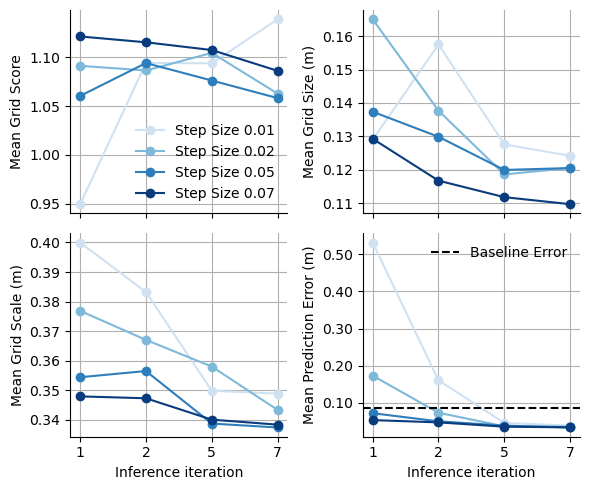

In [49]:
# plot the scores for each step size and iteration, where x-axis is the iteration and y-axis is the score
# and color of the line is the step size (shades of blues)
fig, ax = plt.subplots(2, 2, figsize=(6, 5), sharex=True)

# Mean plot
# ax[0, 0].set_title("Mean Grid Scores vs Iteration")
# ax[0, 0].set_xlabel("Iteration")
ax[0, 0].set_ylabel("Mean Grid Score")
ax[0, 0].grid()
for j, step_size in enumerate(["001", "002", "005", "007"]):
    ax[0, 0].plot(
        np.arange(4),
        [np.mean(score_df.loc[f"iteration_{iters}", f"step_size_{step_size}"]) for iters in [1, 2, 5, 7]],
        label=f"Step Size {step_size[:1]}.{step_size[1:]}",
        color=plt.cm.Blues(j / 4 + 0.2),
        marker='o'
    )
ax[0, 0].legend(frameon=False)

# Plot size on second subplot
# ax[0, 1].set_title("Mean Grid Sizes vs Iteration")
# ax[0, 1].set_xlabel("Iteration")
ax[0, 1].set_ylabel("Mean Grid Size (m)")
ax[0, 1].grid()
for j, step_size in enumerate(["001", "002", "005", "007"]):
    ax[0, 1].plot(
        np.arange(4),
        [np.mean(size_df.loc[f"iteration_{iters}", f"step_size_{step_size}"]) for iters in [1, 2, 5, 7]],
        label=f"Step Size 0.{step_size}",
        color=plt.cm.Blues(j / 4 + 0.2),
        marker='o'
    )

# Plot scale on third subplot
# ax[1, 0].set_title("Mean Grid Scales vs Iteration")
ax[1, 0].set_xlabel("Inference iteration")
ax[1, 0].set_ylabel("Mean Grid Scale (m)")
ax[1, 0].grid()
for j, step_size in enumerate(["001", "002", "005", "007"]):
    ax[1, 0].plot(
        np.arange(4),
        [np.mean(scale_df.loc[f"iteration_{iters}", f"step_size_{step_size}"]) for iters in [1, 2, 5, 7]],
        label=f"Step Size 0.{step_size}",
        color=plt.cm.Blues(j / 4 + 0.2),
        marker='o'
    )

# Plot errors on fourth subplot
# ax[1, 1].set_title("Mean Prediction Errors vs Iteration")
ax[1, 1].set_xlabel("Inference iteration")
ax[1, 1].set_ylabel("Mean Prediction Error (m)")
ax[1, 1].set_xticks([0, 1, 2, 3])
ax[1, 1].set_xticklabels(["1", "2", "5", "7"])
ax[1, 1].grid()
for j, step_size in enumerate(["001", "002", "005", "007"]):
    ax[1, 1].plot(
        np.arange(4),
        [np.mean(err_df.loc[f"iteration_{iters}", f"step_size_{step_size}"]) for iters in [1, 2, 5, 7]],
        color=plt.cm.Blues(j / 4 + 0.2),
        marker='o'
    )
ax[1, 1].axhline(baseline_err, color='k', linestyle='--', label='Baseline Error')
ax[1, 1].legend(frameon=False)
# set y axis decimal to 2
ax[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.2f}'.format(x)))

for a in ax.flat:
    a.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/speed/grid_scores.pdf',bbox_inches='tight')
plt.show()


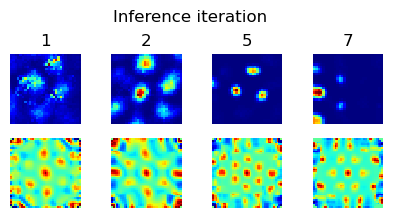

In [51]:
# plot some ratemap examples for step size 0.01 and iteration from 1 to 7
fig, ax = plt.subplots(2, 4, figsize=(5, 2))
for i, iter in enumerate([1, 2, 5, 7]):
    path = df.iloc[i, 0]
    rms = np.load(f"../results/tpc/{path}/top64_grid_cells.npy")
    sacs = np.load(f"../results/tpc/{path}/sac.npy")[:64]
    ax[0, i].imshow(rms[0], cmap='jet', interpolation='nearest')
    ax[1, i].imshow(sacs[1], cmap='jet', interpolation='nearest')
    ax[0, i].axis('off')
    ax[1, i].axis('off')
    ax[0, i].set_title(f"{iter}")
# add oevrall title for the whole figure
fig.suptitle("Inference iteration", fontsize=12, y=1.1)
# plt.tight_layout()
plt.savefig('../results/speed/rm_examples_inf.pdf',bbox_inches='tight')

In [10]:
speeds = [0.01, 0.02, 0.05, 0.1]
models_speeds = ["Mar-24-2025-16-56-46", "Mar-24-2025-10-48-57", "Mar-24-2025-12-43-10", "Mar-24-2025-14-38-05"]
n_cells = 32
env_size = 1.6
size_threshold = 0.5
sizes_mean, scales_mean = [], []
# sizes_std, scales_std = [], []
errs = []
scores_all = []
for i, speed in enumerate(speeds):
    sizes, scales, scores = get_grid_metrics(models_speeds[i], n_cells, env_size, size_threshold)
    err = get_PI_performance(models_speeds[i])[0]
    sizes_mean.append(np.mean(sizes))
    # sizes_std.append(np.std(sizes))
    scales_mean.append(np.mean(scales))
    # scales_std.append(np.std(scales))
    scores_all.append(scores)
    errs.append(np.mean(err))

Initializing new model from scratch.


100%|██████████| 5/5 [00:01<00:00,  3.31it/s]


Initializing new model from scratch.


100%|██████████| 5/5 [00:01<00:00,  3.29it/s]


Initializing new model from scratch.


100%|██████████| 5/5 [00:01<00:00,  3.35it/s]


Initializing new model from scratch.


100%|██████████| 5/5 [00:01<00:00,  3.32it/s]


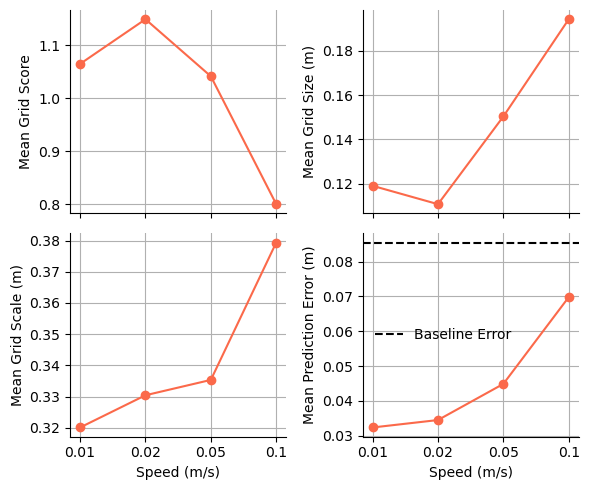

In [52]:
fig, ax = plt.subplots(2, 2, figsize=(6, 5), sharex=True)
for i, a in enumerate(ax.flat):
    a.grid()
    a.set_xticks([0, 1, 2, 3], [str(speeds[i]) for i in range(4)])
    # a.set_xlabel("Speed (m/s)")

ax[0, 0].plot(np.mean(scores_all, axis=1), marker='o', color=plt.cm.Reds(0.5))
ax[0, 0].set_ylabel("Mean Grid Score")

ax[0, 1].plot(sizes_mean, marker='o', color=plt.cm.Reds(0.5))
ax[0, 1].set_ylabel("Mean Grid Size (m)")

ax[1, 0].plot(scales_mean, marker='o', color=plt.cm.Reds(0.5))
ax[1, 0].set_ylabel("Mean Grid Scale (m)")
ax[1, 0].set_xlabel("Speed (m/s)")

ax[1, 1].plot(errs, marker='o', color=plt.cm.Reds(0.5))
ax[1, 1].set_ylabel("Mean Prediction Error (m)")
ax[1, 1].axhline(baseline_err, color='k', linestyle='--', label='Baseline Error')
ax[1, 1].legend(frameon=False)
ax[1, 1].set_xlabel("Speed (m/s)")
for a in ax.flat:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/speed/grid_scores_speed.pdf',bbox_inches='tight')

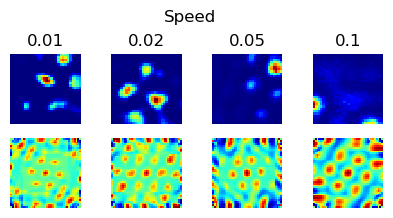

In [53]:
fig, ax = plt.subplots(2, 4, figsize=(5, 2))
for i, s in enumerate([0.01, 0.02, 0.05, 0.1]):
    path = df.iloc[i, 0]
    rms = np.load(f"../results/tpc/{models_speeds[i]}/top64_grid_cells.npy")
    sacs = np.load(f"../results/tpc/{models_speeds[i]}/sac.npy")[:64]
    ax[0, i].imshow(rms[0], cmap='jet', interpolation='nearest')
    ax[1, i].imshow(sacs[1], cmap='jet', interpolation='nearest')
    ax[0, i].axis('off')
    ax[1, i].axis('off')
    ax[0, i].set_title(f"{s}")
# add oevrall title for the whole figure
fig.suptitle("Speed", fontsize=12, y=1.1)
# plt.tight_layout()
plt.savefig('../results/speed/rm_examples_speed.pdf',bbox_inches='tight')

NameError: name 'sns' is not defined

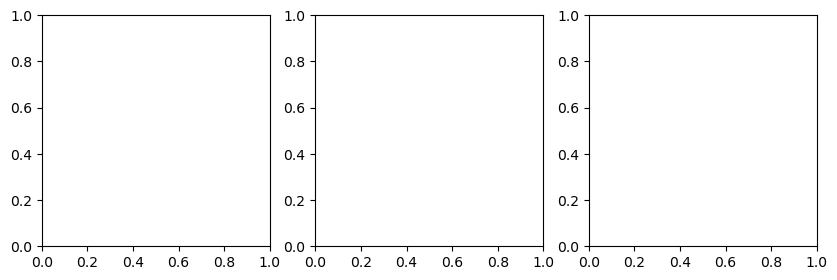

In [12]:
x = [str(speed) for speed in speeds]
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
sns.barplot(x=x, y=sizes_mean, yerr=sizes_std, capsize=5, ax=ax[0], color='skyblue', edgecolor='black')
ax[0].set_title('Grid size')
ax[0].set_ylabel('meters')
sns.barplot(x=x, y=scales_mean, yerr=scales_std, capsize=5, ax=ax[1], color='skyblue', edgecolor='black')
ax[1].set_title('Grid scale')
ax[1].set_ylabel('meters')
#violin plot of scores
sns.violinplot(data=scores_all, ax=ax[2], color='skyblue')
ax[2].set_title('Grid scores')
ax[2].set_ylabel('Score')
ax[2].set_xticks([0,1,2,3], x)
# add a x-axis label across all subplots
fig.text(0.53, -0.05, 'Speed (m/s)', ha='center', fontsize=12)
plt.tight_layout()


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

def estimate_modes_kde(data, bandwidth=None):
    kde = gaussian_kde(data, bw_method=bandwidth)
    x_grid = np.linspace(data.min() - 1, data.max() + 1, 1000)
    kde_values = kde(x_grid)

    # Find peaks in KDE
    peaks, _ = find_peaks(kde_values)
    num_modes = len(peaks)

    return num_modes

def evaluate_gmm_bic(data, n_components=3, plot=True):
    data_reshaped = data.reshape(-1, 1)
    
    gmm = GaussianMixture(n_components=n_components, random_state=0)
    gmm.fit(data_reshaped)

    return gmm.bic(data_reshaped)


In [ ]:
# for each scale in the scale_df, estimate the number of modes using Kernel Density Estimation
num_modes_df = pd.DataFrame(columns=["step_size_002", "step_size_005", "step_size_007", "step_size_01"])
for i, iters in enumerate([1, 2, 5, 7]):
    for j, step_size in enumerate([0.02, 0.05, 0.07, 0.1]):
        step_size = str(step_size).replace(".", "")
        scale = scale_df.loc[f"iteration_{iters}", f"step_size_{step_size}"]
        scale = np.array(scale).flatten()
        num_modes = estimate_modes_kde(scale, bandwidth=0.3)
        num_modes_df.loc[f"iteration_{iters}", f"step_size_{step_size}"] = num_modes

In [ ]:
bic_df = pd.DataFrame(columns=["step_size_002", "step_size_005", "step_size_007", "step_size_01"])
for i, iters in enumerate([1, 2, 5, 7]):
    for j, step_size in enumerate([0.02, 0.05, 0.07, 0.1]):
        step_size = str(step_size).replace(".", "")
        scale = scale_df.loc[f"iteration_{iters}", f"step_size_{step_size}"]
        scale = np.array(scale).flatten()
        bic = evaluate_gmm_bic(scale, n_components=3)
        bic_df.loc[f"iteration_{iters}", f"step_size_{step_size}"] = bic

In [ ]:
bic_df

,step_size_002,step_size_005,step_size_007,step_size_01
iteration_1,-119.196978,-98.024351,-113.539098,-118.465832
iteration_2,-113.200521,-116.34553,-112.199458,-108.200091
iteration_5,-114.119531,-102.141005,-121.583976,-95.631825
iteration_7,-129.153023,-121.338186,-125.098734,-98.877141


In [ ]:
num_modes_df

,step_size_002,step_size_005,step_size_007,step_size_01
iteration_1,3,2,2,2
iteration_2,3,3,3,4
iteration_5,2,2,2,3
iteration_7,3,3,3,2


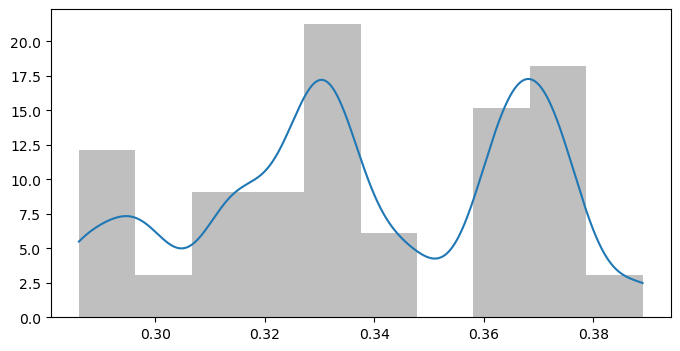

In [ ]:
data = np.array(scale_df.loc["iteration_7", "step_size_007"])
kde = gaussian_kde(data, bw_method=0.2)
x_grid = np.linspace(data.min(), data.max(), 1000)
kde_values = kde(x_grid)
plt.figure(figsize=(8, 4))
plt.hist(data, bins=10, density=True, alpha=0.5, color='gray', label='Histogram')
plt.plot(x_grid, kde_values, label='KDE')